# Spam Email Classifier - Exploratory Data Analysis & Training

This notebook walks through the full pipeline used in this project, in an exploratory / step-by-step format:

1. Load and explore the SMS Spam Collection Dataset
2. Visualize class distribution
3. Clean and preprocess the text
4. Vectorize using TF-IDF
5. Train a Multinomial Naive Bayes classifier
6. Evaluate the model (accuracy, precision, recall, F1, confusion matrix)
7. Test predictions on custom messages

For the production scripts, see `train.py` and `predict.py` in the project root.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

from preprocess import clean_text

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load the Dataset

In [2]:
df = pd.read_csv('dataset/spam.csv', encoding='latin-1')
df = df.iloc[:, :2]
df.columns = ['label', 'message']
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (5169, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Explore Class Distribution

In [3]:
print(df['label'].value_counts())
print()
print(df['label'].value_counts(normalize=True) * 100)

label
ham     4516
spam     653
Name: count, dtype: int64

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


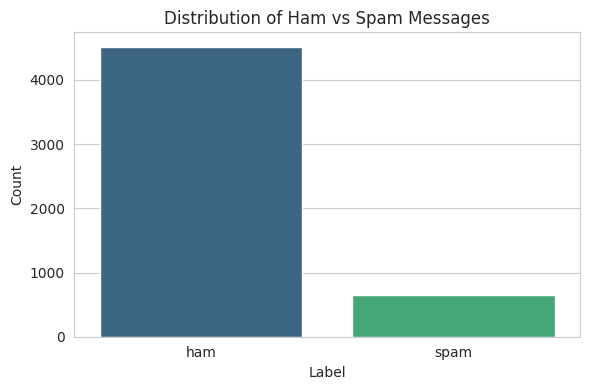

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
plt.title('Distribution of Ham vs Spam Messages')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('screenshots/class_distribution.png', dpi=150)
plt.show()

## 4. Analyze Message Length

Spam messages are often longer than typical ham messages, since they tend to contain promotional text, links, and call-to-action phrases.

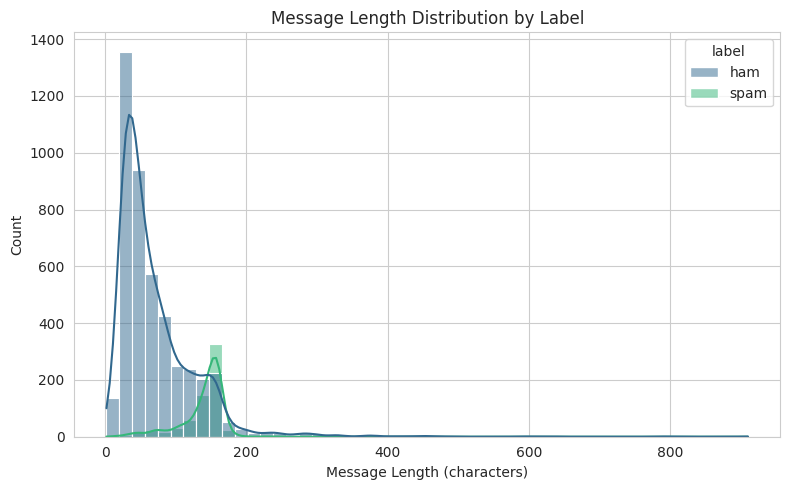

In [5]:
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, palette='viridis')
plt.title('Message Length Distribution by Label')
plt.xlabel('Message Length (characters)')
plt.tight_layout()
plt.savefig('screenshots/message_length_distribution.png', dpi=150)
plt.show()

## 5. Text Preprocessing

We reuse the `clean_text()` function from `preprocess.py` so training and prediction always stay in sync.

In [6]:
df['cleaned_message'] = df['message'].apply(clean_text)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

df[['message', 'cleaned_message']].head(10)

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts may...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling weeks word back id like fu...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


## 6. Train-Test Split

In [7]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['cleaned_message'],
    df['label_num'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_num']
)

print(f'Training samples: {len(X_train_text)}')
print(f'Testing samples:  {len(X_test_text)}')

Training samples: 4135
Testing samples:  1034


## 7. TF-IDF Vectorization

In [8]:
vectorizer = TfidfVectorizer(max_features=3000)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f'TF-IDF matrix shape (train): {X_train.shape}')
print(f'TF-IDF matrix shape (test):  {X_test.shape}')

TF-IDF matrix shape (train): (4135, 3000)
TF-IDF matrix shape (test):  (1034, 3000)


## 8. Train the Multinomial Naive Bayes Model

In [9]:
model = MultinomialNB()
model.fit(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


## 9. Evaluate the Model

In [10]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

Accuracy:  0.9700
Precision: 0.9902
Recall:    0.7710
F1-Score:  0.8670

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       0.99      0.77      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.93      1034
weighted avg       0.97      0.97      0.97      1034



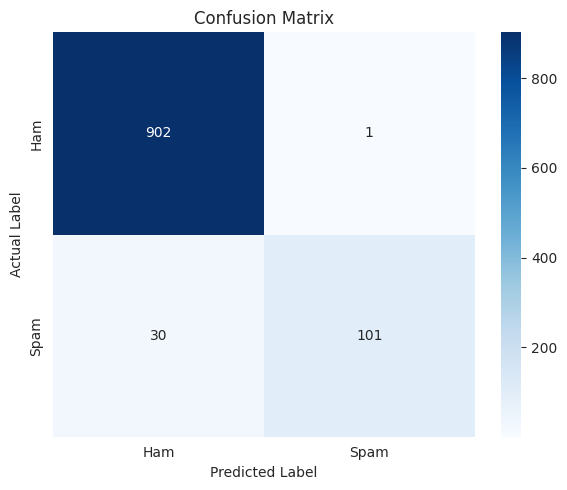

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.savefig('screenshots/confusion_matrix.png', dpi=150)
plt.show()

## 10. Test on Custom Messages

In [12]:
custom_messages = [
    'Congratulations! You have WON a free prize, call now to claim your reward!!!',
    'Hey, are we still meeting for lunch tomorrow at 1pm?',
    'URGENT! Your mobile number has won 5000 pounds, text CLAIM to 8712 now',
    'Can you send me the notes from today\'s class?'
]

for msg in custom_messages:
    cleaned = clean_text(msg)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0][pred]
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f'[{label:4s}] ({proba:.2%}) -> {msg}')

[SPAM] (98.25%) -> Congratulations! You have WON a free prize, call now to claim your reward!!!
[HAM ] (99.64%) -> Hey, are we still meeting for lunch tomorrow at 1pm?
[SPAM] (96.37%) -> URGENT! Your mobile number has won 5000 pounds, text CLAIM to 8712 now
[HAM ] (88.65%) -> Can you send me the notes from today's class?


## 11. Save the Model

The same saving logic is already implemented in `train.py`. Running that script is the recommended way to (re)generate `models/spam_model.pkl` and `models/tfidf_vectorizer.pkl` for use with `predict.py`.

In [13]:
import pickle
import os

os.makedirs('models', exist_ok=True)

with open('models/spam_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print('Model and vectorizer saved to the models/ directory.')

Model and vectorizer saved to the models/ directory.
